In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import sys
import datetime
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
# sys.path.append("..")
from utils.Dataset import Augmented
from utils.log import Logger, plot_graph
from models.generator_cnn import Generator_502 as Generator_cnn 
from models.generator_cnn import Generator_512
from models.discriminator_cnn import Discriminator_512
from models.generator import Generator
# from models.discriminator import Discriminator
from torch_intermediate_layer_getter import IntermediateLayerGetter
from models.discriminator_cnn import Discriminator_502 as Discriminator_cnn
import torchvision
from torchvision4ad.datasets import MVTecAD
import time
import pennylane as qml
from torchsummary import summary


In [4]:
# print(*[torch.cuda.get_device_properties(f'cuda:{i}') for i in range(5)], sep ='\n')

In [5]:
#Parameters
batch_size = 1
num_qubits = 7
depth= 4
lr = 0.0001
dev = qml.device('lightning.gpu', wires = num_qubits, )

In [6]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Grayscale(),
    # transforms.RandomHorizontalFlip(0.6), #probability
    # transforms.RandomVerticalFlip(0.6) ,
    # v2.GaussianNoise(sigma=0.04),
    transforms.Normalize([0.5], [0.5]), # normalize image with mean and standard deviation.
    transforms.CenterCrop((512, 512)),  # Reduce image size to save memory
])

In [7]:
dataset = ImageFolder('Datasets/MvTec/', transform = transform)
dataloader = DataLoader(dataset, batch_size = batch_size, pin_memory=True, num_workers=20)

In [95]:
netG = Generator_512(nf=64).to(device)


256 256
[[ 0.28614593  0.29398823  0.30183065 ...  0.17635298  0.1920377
   0.1920377 ]
 [ 0.30183065  0.32535768  0.31751537 ...  0.17635298  0.19988012
   0.19988012]
 [ 0.32535768  0.32535768  0.32535768 ...  0.17635298  0.1920377
   0.19988012]
 ...
 [-0.46671993 -0.38829643 -0.29418826 ... -0.43535054 -0.45887756
  -0.4745623 ]
 [-0.52161646 -0.4745623  -0.40398115 ... -0.3961388  -0.42750818
  -0.4431929 ]
 [-0.55298585 -0.5137741  -0.4745623  ... -0.3647694  -0.3961388
  -0.4118235 ]]
[[ 0.28614593  0.29398823  0.30183065 ...  0.17635298  0.1920377
   0.1920377 ]
 [ 0.30183065  0.32535768  0.31751537 ...  0.17635298  0.19988012
   0.19988012]
 [ 0.32535768  0.32535768  0.32535768 ...  0.17635298  0.1920377
   0.19988012]
 ...
 [-0.46671993 -0.38829643 -0.29418826 ... -0.43535054 -0.45887756
  -0.4745623 ]
 [-0.52161646 -0.4745623  -0.40398115 ... -0.3961388  -0.42750818
  -0.4431929 ]
 [-0.55298585 -0.5137741  -0.4745623  ... -0.3647694  -0.3961388
  -0.4118235 ]]


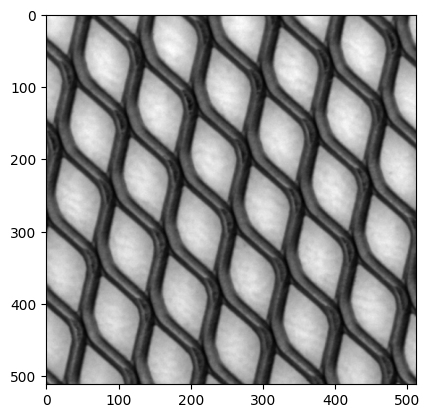

In [40]:
sample_img=next(iter(dataloader))[0][0][0].cpu().numpy()
# sample_img[0][0][0].cpu().numpy()
img_info =True
if img_info:
    img_shape = dataloader.dataset[2]
    print(len(dataloader.dataset), len(dataloader))
    print(sample_img)
    # plt.imshow(img_shape[0][0])
    # plt.imsave("images/image3.png", sample_img[0][0].cpu().numpy(),cmap ='gray')
    print(sample_img)
    plt.imshow(sample_img, cmap='gray')

In [9]:
netG = Generator_cnn(nf = 64).to(device)
summary(netG, (128, 1,1), 8, device = 'cuda')


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [8, 4096, 4, 4]       8,388,608
       BatchNorm2d-2            [8, 4096, 4, 4]           8,192
              ReLU-3            [8, 4096, 4, 4]               0
   ConvTranspose2d-4            [8, 2048, 8, 8]     134,217,728
       BatchNorm2d-5            [8, 2048, 8, 8]           4,096
              ReLU-6            [8, 2048, 8, 8]               0
   ConvTranspose2d-7          [8, 1024, 16, 16]      33,554,432
       BatchNorm2d-8          [8, 1024, 16, 16]           2,048
              ReLU-9          [8, 1024, 16, 16]               0
  ConvTranspose2d-10           [8, 512, 32, 32]       8,388,608
      BatchNorm2d-11           [8, 512, 32, 32]           1,024
             ReLU-12           [8, 512, 32, 32]               0
  ConvTranspose2d-13           [8, 256, 64, 64]       2,097,152
      BatchNorm2d-14           [8, 256,

In [10]:
weights = torch.load('saved_models/gen_24.pth')
[(keys, weights[keys].shape) for keys in weights]
weights['model.6.weight'].cpu()[0,2]

/tmp/ipykernel_3120959/1516015793.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load('saved_models/gen_24.pth')


tensor([[ 0.0377,  0.0409,  0.0634, -0.0487],
        [-0.1017,  0.1128,  0.0219, -0.1186],
        [ 0.0302, -0.0504,  0.0535, -0.1178],
        [-0.0094,  0.1056,  0.0329, -0.1558]])

In [13]:
# models 
ngf = 48
ndf = 3
netG = Generator_cnn(nf = ngf).to(device)
netD = Discriminator_cnn(nf = ndf).to(device)
netG.load_state_dict(torch.load('saved_models/gen_24.pth', map_location = device))
netD.load_state_dict(torch.load('saved_models/dis_24.pth', map_location = device))
netG.eval()
netD.eval()

/tmp/ipykernel_3120959/3214750218.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('saved_models/gen_24.pth', map_location = device))
/tmp

Discriminator_502(
  (main): Sequential(
    (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(3, 6, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(6, 12, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(12, 24, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(24, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (12): BatchNorm2d(48, eps=1e-05, momentum=0.1

In [27]:
#Check the performance of Discriminator
image= dataset[2][0].to(device).unsqueeze(0)
noise= torch.randn(10, 1, 512, 512).to(device)
netD(image)

tensor([[0.8988]], device='cuda:0', grad_fn=<ViewBackward0>)

In [44]:
fake = netG(torch.randn(1, 128, 1, 1, device=device))[0].cpu().detach().squeeze()


In [47]:
diff = sample_img

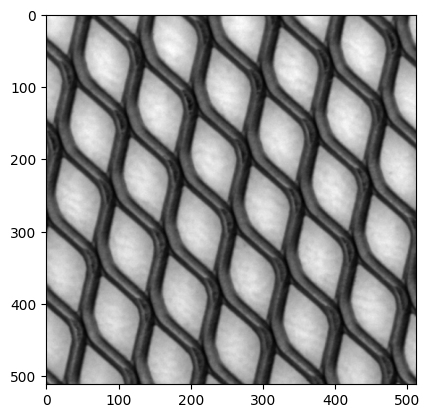

In [48]:
plt.imshow(diff, cmap='gray')


In [119]:
torch.cuda.get_device_name(device=device)

'NVIDIA L40'

In [120]:
# summary(netG, (128, 1, 1), 2, device='cuda')

In [33]:
sample_img.shape

(1, 512, 512)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8340543..4.783132].


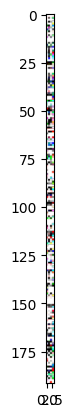

In [34]:
return_layer = {
    "main.18" : 'output_layer'
}
mid_out = IntermediateLayerGetter(netD, return_layers=return_layer, keep_output=True)
# summary(netD, ( 1, 512, 512), device='cpu')
# lat = Encoder()().view(batch_size, 128, 1, 1).to(device)
x = mid_out(netG(torch.randn(1,128,1,1, device = device)))[0]['output_layer']
# y = mid_out(sample_img[0])
plt.imshow(x[0].cpu().detach().numpy())


In [35]:
## SELECT FINITE DIFFERENCE AS GRADIENT FINDING METHOD

@qml.qnode(device=dev, interface='torch')
def circuit(w):
    noise = torch.randn(num_qubits) * np.pi /2
    weights = w.reshape(depth, 3, num_qubits)
    for i in range(num_qubits):
        qml.RY(noise[i], wires =i)

    for depth_no in range(depth):
        for params in range(3):
            for i in range(num_qubits):
                if params == 0:
                    qml.RX(weights[depth_no][params][i], wires=i) 
                elif params == 1:
                    qml.RZ(weights[depth_no][params][i], wires=i)
                elif params == 2:
                    qml.CRX(weights[depth_no][params][i], wires=[i, i+1 if i < num_qubits -1 else 0])
    output = qml.probs(wires=list(range(num_qubits)))
    return output

weight = torch.randn(depth * num_qubits * 3)
noise = torch.randn(batch_size, num_qubits)
# print(qml.draw_mpl(circuit)(weight))

In [124]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.batch_size = batch_size
        self.num_params = num_qubits * 3 * depth
        self.params = nn.Parameter(torch.randn(batch_size, self.num_params , device=device)* 2*np.pi - np.pi )
        
    
    def forward(self):
        lst = torch.zeros(batch_size, 2**num_qubits)
        for batch in range(self.batch_size):
            x = circuit(self.params[batch])
            lst[batch] = (x / x.max() -0.5)*2
        # print(lst.shape)
        return lst

In [125]:
class Encoding_NN(nn.Module):
    def __init__(self):
        super(Encoding_NN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), 
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 128),
            nn.Tanh()
            
        )
    def forward(self):
        noise = torch.randn(batch_size, 7, device = device)
        return self.model(noise)

In [126]:
input = torch.randn(batch_size, num_qubits)
o = Encoder()()
o, o.max(), o.min()

out = Encoding_NN().to(device)()
out, out.max(), out.min()

(tensor([[-0.0023,  0.0219, -0.0050, -0.0149,  0.0128,  0.0575, -0.0396,  0.0657,
          -0.0635, -0.0048, -0.0472,  0.0247, -0.0166, -0.0157,  0.0926,  0.0327,
           0.0387, -0.0144,  0.0336, -0.0321,  0.0355,  0.0562,  0.0453, -0.0061,
           0.0624,  0.0245,  0.0098, -0.0035, -0.0515,  0.0325, -0.0206,  0.0906,
          -0.0027, -0.0148, -0.0188, -0.0439,  0.0334, -0.0330, -0.0464,  0.0345,
           0.0666, -0.0790,  0.0206,  0.0098,  0.0435,  0.0280, -0.0263, -0.0531,
           0.0853, -0.0970,  0.0173,  0.0026, -0.0497,  0.0305, -0.0183,  0.0008,
           0.0805,  0.0060,  0.0148,  0.0113,  0.0130, -0.0186,  0.0759, -0.0649,
          -0.0207,  0.0737,  0.0122, -0.0486, -0.0423, -0.0097,  0.0234, -0.0408,
          -0.0059, -0.0449,  0.0324, -0.0437, -0.0742,  0.0233,  0.0080,  0.0125,
           0.0485,  0.0222, -0.0065, -0.0821, -0.0376,  0.0147, -0.0209, -0.0573,
           0.0056,  0.0631, -0.0085, -0.0345,  0.0446,  0.0082,  0.0540,  0.0035,
          -0.039

In [127]:
l2_error = nn.MSELoss()


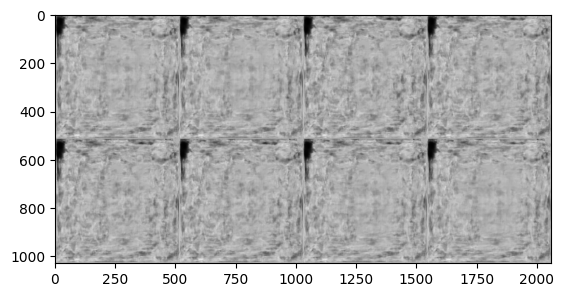

In [128]:
imgs=netG(torch.rand(8,256,1,1, device = device))
imgs[4:]=netG(torch.rand(4,256,1,1, device = device))

grid = torchvision.utils.make_grid(imgs, nrow=4)
plt.Figure(figsize=(5,5))
plt.imshow(grid.cpu().detach().numpy()[0], cmap='gray')
plt.show()

In [117]:
#simple trainig loop
# model = Encoder().to(device)
model = Encoding_NN().to(device)
optim = torch.optim.Adam(model.parameters())
loss = nn.MSELoss()
lossess=[]
def loss(a, max_weight= 0.1, v= 1.0):
    if a.numel() == 0:
        return torch.tensor(0.0, requires_grad=a.requires_grad)
    max_value = a.max()
    max_penalty = max_value * max_weight

    # Component 2: Penalize the spread (variance)
    # For a tensor with only one element, variance is 0.0, which is correct.
    # For multi-element tensors, torch.var() calculates the variance.
    variance_penalty = a.var() * v

    # Combine the two components
    total_loss = max_penalty + variance_penalty
    return total_loss

    # current_sum = 
    # loss_value = torch.pow(current_sum - 0.5, 2) # (current_sum - target_sum)^2
    loss_value = a.sum()
    return loss_value
for i in range(100):
    optim.zero_grad()
    out = model()
    # out= model()
    l = loss(out)
    l.backward()
    optim.step()
    lossess.append(l.item())
    

In [118]:
print(out.shape)

torch.Size([1, 128])


In [2]:
plt.plot(np.arange(len(lossess)), lossess)

NameError: name 'plt' is not defined

In [120]:
output = model(noise).cpu().detach().numpy()
print(output.sum(), output[0].max())
plt.plot(np.arange(len(output[0])), output[0])

TypeError: Encoding_NN.forward() takes 1 positional argument but 2 were given

In [121]:
# device = 'cpu'
r=0

In [156]:
import time
from torchvision.utils import save_image

print("Testing phase started...")
num_test_iters = 100

netG.eval()
netD.eval()
array = []
losses = []
in_time = time.time()

mid_out = IntermediateLayerGetter(netD, return_layers=return_layer, keep_output=True)
for batch_idx, x in enumerate(dataloader):
    test_loss = None
    anomaly_score = None
    f_G_z = None
    f_x = None

    # Instantiate the encoder once per batch, not per iteration
    encoder = Encoder().to(device)  # One encoder for every batch
    # encoder = Encoding_NN().to(device)
    optimiser_encoder = torch.optim.SGD(encoder.parameters(), lr=0.2)

    # Move input to the device once
    x = x[0].to(device)
    for iter in range(num_test_iters):
        latent = torch.randn(batch_size, num_qubits).to(device)
        optimiser_encoder.zero_grad()

        # Forward pass through the encoder
        latent = encoder().view(batch_size, 128, 1, 1).to(device)
        # if iter ==num_test_iters-1: print(latent)
        # print("enocder output: ", latent_z)
        generated_images = netG(latent)
        
        # Compute the residual loss
        residual_loss = l2_error(x, generated_images)

        # residual_loss.backward()
        # # Get the intermediate outputs from the discriminator
        f_G_z, model_output = mid_out(generated_images)
        f_x, model_output_1 = mid_out(x)

        f_G_z = f_G_z['output_layer']
        f_x = f_x['output_layer']

        # # Compute the discriminator loss
        discriminator_loss = l2_error(f_G_z, f_x)

        # # Compute total test loss
        alpha = 0.1
        test_loss = alpha * discriminator_loss + (1 - alpha) * residual_loss
        test_loss.backward()
        losses.append(test_loss.item())
        # Update the encoder
        optimiser_encoder.step()
        # if iter%5==0 and iter > 0: print(iter,": done")
    # print(f'Batch {batch_idx} finished.')
    r+=1
    # Save generated images after processing the batch
    # save_image(torchvision.utils.make_grid(list(zip(x, generated_images))), f"images/batch{batch_idx}.png")
    save_image(x, f'images/qgan/input_image{batch_idx}.png', normalize = True)
    save_image(generated_images, f'images/qgan/batch_{batch_idx}_{r}.png', normalize=True)
    # plot_comp(x, generated_images)
    batch_time = time.time()
    print(f"Batch {batch_idx}, Time taken: {time.time() - in_time}")
    break

out_time = time.time()
print(f"Time taken in minutes: {(out_time - in_time) / 60}")


Testing phase started...
Batch 0, Time taken: 121.71486330032349
Time taken in minutes: 2.0297642787297567


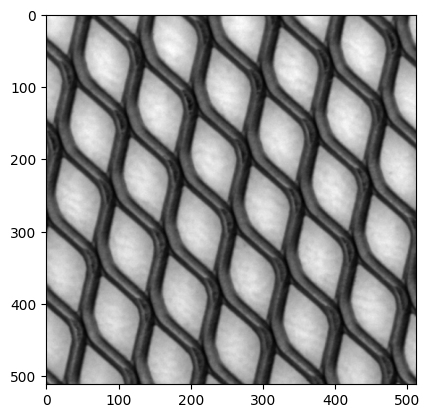

In [145]:
plt.imshow(x.cpu().numpy().squeeze(), cmap='gray')

In [152]:
print(generated_images.max())

tensor(0.4159, device='cuda:0', grad_fn=<MaxBackward1>)


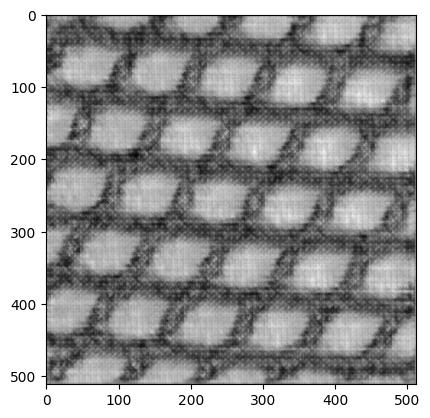

In [153]:
plt.imshow(generated_images[0].cpu().detach().numpy().squeeze(), cmap='gray')

In [154]:
# with open(f"logs/Jun23/qgan/loss_{r}.npy", 'wb') as f:
#         np.save(f, np.array(losses))

Text(0.5, 1.0, 'Lr=0.0001, optimizer=SGD')

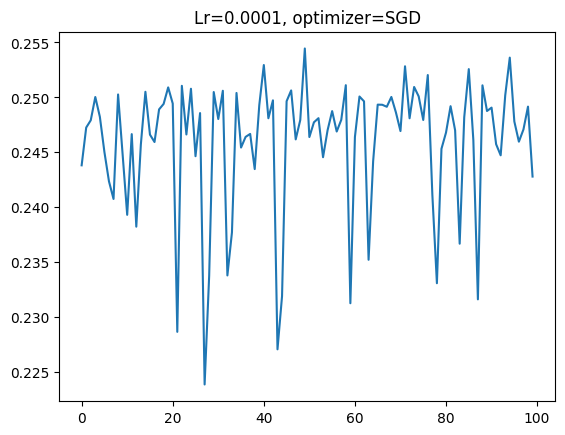

In [155]:
# loss_ = [i.item() for i in losses]
plt.plot(np.arange(len(losses)), losses)
plt.title(f"Lr={0.05}, optimizer=SGD")

In [ ]:
plt.imsave('images/qgan_output.png')

In [ ]:
plt

In [207]:
[a for a in zip(list(range(10)), list(range(10)))]

[(0, 0),
 (1, 1),
 (2, 2),
 (3, 3),
 (4, 4),
 (5, 5),
 (6, 6),
 (7, 7),
 (8, 8),
 (9, 9)]

In [43]:
def plot_comp(real, fake):
    fig,ax = plt.subplots(nrows= batch_size, ncols= 2,figsize=(4, 8))
    for i in range(batch_size):
        
        ax[i, 0].imshow(real[0][i].cpu().numpy().squeeze())
        ax[i, 1].imshow(fake[0][i].cpu().numpy().squeeze())
    plt.show()
x, y = next(iter(dataloader)), next(iter(dataloader))

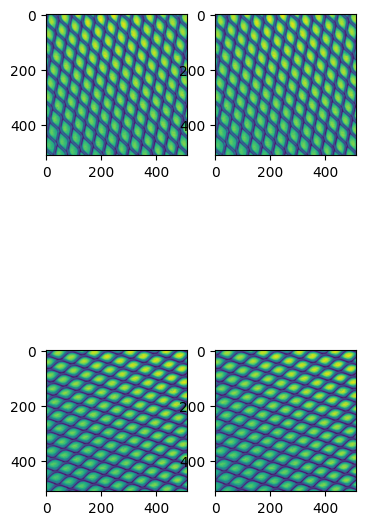

In [44]:
x[0].shape
plot_comp(x, y)